In [1]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()
Pkg.resolve()

  Activating project at `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts`
  No Changes to `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/Project.toml`
  No Changes to `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/Manifest.toml`


In [2]:
using Distributions
using LinearAlgebra
using StatsFuns
using StatsBase

using LogDensityProblems
using LogDensityProblemsAD
using AbstractDifferentiation
using MCMCDiagnosticTools
using AdvancedHMC
using MicroCanonicalHMC
using Pathfinder
using Transducers

using Healpix
using HealpixMPI
using MPI

using Plots
using StatsPlots
using LaTeXStrings
using DataFrames

using Random
using ProgressMeter
using BenchmarkTools
using NPZ
using CSV
using Test

using Zygote: @adjoint
using Zygote
using ChainRules.ChainRulesCore

include("AD_parallSHT.jl")
include("gen_datatest.jl")
include("reparam.jl")
include("utils.jl")
include("inference_model.jl")
include("neglogproblem.jl")

nℓπ_grad (generic function with 1 method)

In [3]:
# using Turing
# using Capse
using NPZ
# # using PlanckLite
# using BenchmarkTools
# using Plots
# using Optim
# using ForwardDiff
# using Pathfinder
# #using MicroCanonicalHMC
# #using Transducers
# using StatsPlots
# #using PairPlots
# #using LaTeXStrings
# #using CairoMakie
# using MCMCChains
using PSIS
# include("utils.jl");
using ArviZ
#using ArviZPythonPlots
using LinearAlgebra
using IrrationalConstants
using DimensionalData
using Statistics

In [4]:
Threads.nthreads()

4

In [5]:
# files = filter(
#     f -> endswith(f, "_mask_NUTS_nside_16.npy"),
#     readdir("/Users/ethansmith/Desktop/Waterloo/Masters/Andrea_flinch_scripts/scripts/MPI_chains"; join=true)
# )

# for file in files
#     println(file)
# end

# sort!(files)

# sampled_params = hcat((npzread(f) for f in files)...)

files = ["/Users/ethansmith/Desktop/Waterloo/Masters/Andrea_flinch_scripts/scripts/MPI_chains/2yjXc_mask_NUTS_nside_16.npy"]
sampled_params = npzread("/Users/ethansmith/Desktop/Waterloo/Masters/Andrea_flinch_scripts/scripts/MPI_chains/2yjXc_mask_NUTS_nside_16.npy")

samples = size(sampled_params, 2)

2000

In [6]:
ids = [
    replace(splitext(basename(f))[1],
            "_mask_NUTS_nside_16" => "")
    for f in files
]

runname = join(ids, "_")

"2yjXc"

In [7]:
seed = 1123
Random.seed!(seed)

#   RESOLUTION PARAMETERS
nside = 16
lmax = 2*nside - 1

MPI.Init()

comm = MPI.COMM_WORLD
crank = MPI.Comm_rank(comm)
csize = MPI.Comm_size(comm)
root = 0
ncore = 32

#   REALIZATION MAP
realiz_Cl, realiz_HAlm, realiz_HMap = Realization("Capse_fiducial_Dl.csv", nside, lmax, seed)
realiz_θ = vcat(x_vecmat2vec(from_healpix_alm_to_alm([realiz_HAlm], lmax, 1, comm, root=root), lmax, 1, comm, root=root), Cl2Kl(realiz_Cl))

d = length(realiz_θ)

#   SURVEY MASK
mask_512 = readMapFromFITS("wmap_temperature_kq85_analysis_mask_r9_9yr_v5.fits",2,Float64)
mask_nside = udgrade(nest2ring(mask_512), nside)
for i in 1:length(mask_nside.pixels)
    if mask_nside.pixels[i]<=0.5
        mask_nside.pixels[i]=1
    else
        mask_nside.pixels[i]=0
    end
end

#   GENERATED DATA MEASUREMENTS
#   Noise
ϵ=150
N = ϵ*ones(nside2npix(nside))
N[mask_nside.==1] .= 5*10^4
#   Gaussian beam and pixel window function
Bl = ones(length(realiz_Cl))#gaussbeam(0.001, lmax, pol=false)
Pl = ones(length(realiz_Cl))#pixwin(nside, pol=false)[1:lmax+1]
BP_l = Bl.*Pl

#   Data Map
gen_Cl, gen_HAlm, gen_HMap = Measurement(realiz_Cl, Bl, Pl, mask_nside, N, nside, lmax, seed)
gen_θ = vcat(x_vecmat2vec(from_healpix_alm_to_alm([gen_HAlm], lmax, 1, comm, root=root), lmax, 1, comm, root=root), Cl2Kl(gen_Cl))
invN_HMap = HealpixMap{Float64,RingOrder}(1 ./ N)

#   STARTING POINT
start_Cl, start_HAlm, start_HMap = StartingPoint(gen_Cl, nside)
start_θ = vcat(x_vecmat2vec(from_healpix_alm_to_alm([start_HAlm], lmax, 1, comm, root=root), lmax, 1, comm, root=root), Cl2Kl(start_Cl))

#   PROMOTE HEALPIX.MAP TO HEALIPIXMPI.DMAP
gen_DMap = DMap{RR}(comm)
invN_DMap = DMap{RR}(comm)
HealpixMPI.Scatter!(gen_HMap, gen_DMap, comm, clear=true)
HealpixMPI.Scatter!(invN_HMap, invN_DMap, comm, clear=true)

helper_DMap = deepcopy(gen_DMap)

DMap: I am task 0 of 1, I work on 63 rings of 63
DMap: I am task 0 of 1, I work on 63 rings of 63


DMap{RR, Float64}([0.0; 0.0; … ; 106.75576281525872; 57.76576547614584;;], GeomInfoMPI(MPI.Comm(1140850688), 16, 64, [1.5707963267948966, 1.5291175943723188, 1.6124750592174744, 1.4873662401842815, 1.6542264134055116, 1.445468495626831, 1.696124157962962, 1.4033482475752073, 1.7382444060145859, 1.3609257345321588  …  0.25585245340993723, 2.885740200179856, 0.20448019896853478, 2.9371124546212584, 0.15324300949611616, 2.988349644093677, 0.10210642238260403, 3.039486231207189, 0.05103657515266638, 3.090556078437127], [32, 31, 33, 30, 34, 29, 35, 28, 36, 27  …  5, 59, 4, 60, 3, 61, 2, 62, 1, 63], [1, 65, 129, 193, 257, 321, 385, 449, 513, 577  …  2953, 2973, 2993, 3009, 3025, 3037, 3049, 3057, 3065, 3069], [64, 64, 64, 64, 64, 64, 64, 64, 64, 64  …  20, 20, 16, 16, 12, 12, 8, 8, 4, 4], [1.5707963267948966, 1.5291175943723188, 1.6124750592174744, 1.4873662401842815, 1.6542264134055116, 1.445468495626831, 1.696124157962962, 1.4033482475752073, 1.7382444060145859, 1.3609257345321588  …  0.25

In [8]:
θ = sampled_params[:,1500]
alm = θ[1:length(θ)-lmax-1]
sample_alm = x_vec2vecmat(alm, lmax, 1, comm, root=root)
sample_HAlm = from_alm_to_healpix_alm(sample_alm, lmax, 1)[1] # comm, root=root)[1]
sample_DAlm = HAlm2DAlm(sample_HAlm, comm; clear=true, root=root)

DAlm: I am task 0 of 1, I work on 32 m's of 31


DAlm{RR, ComplexF64}(ComplexF64[0.06665321366918565 + 0.0im; 0.047715797308705024 + 0.0im; … ; 5.6712848652202466 + 0.401354461585828im; 2.0583078465464797 - 0.03731645501968117im;;], AlmInfoMPI(MPI.Comm(1140850688), 31, 31, 32, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9  …  22, 23, 24, 25, 26, 27, 28, 29, 30, 31], [1, 32, 62, 91, 119, 146, 172, 197, 221, 244  …  452, 461, 469, 476, 482, 487, 491, 494, 496, 497]))

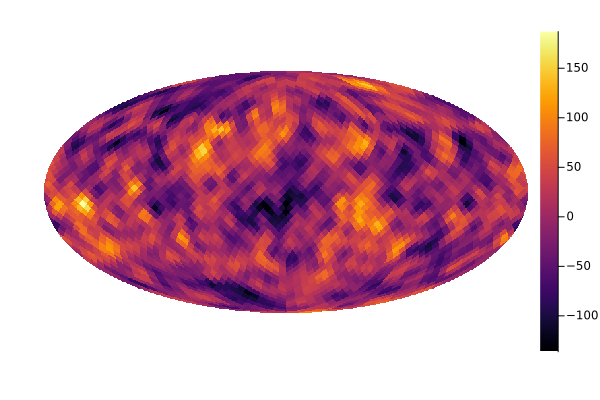

In [9]:
sample_HMap = Healpix.alm2map(sample_HAlm, nside)
plot(HealpixMap{Float64, RingOrder}(sample_HMap.pixels[:, 1]))

In [10]:
# reshape(NLLs_float[:,1], :, 1)
# helper_DMap.pixels = reshape(NLLs_float[:,1], :, 1)

In [11]:
NLL_Pixel(sample_DAlm, helper_DMap, ncore, gen_DMap, invN_DMap, BP_l, 1354)

1.3624620263783611

In [12]:
pixels = length(gen_DMap.pixels)

3072

In [13]:
NLLs = Matrix{Any}(undef, pixels, samples)
NLLs_HMap = [HealpixMap{Float64, RingOrder}(nside) for i in 1:samples]
samples_HMap = [HealpixMap{Float64, RingOrder}(nside) for i in 1:samples]

for n in 1:samples
    θ = sampled_params[:,n]
    alm = θ[1:length(θ)-lmax-1]
    sample_alm = x_vec2vecmat(alm, lmax, 1, comm, root=root)
    sample_HAlm = from_alm_to_healpix_alm(sample_alm, lmax, 1, comm, root=root)[1]
    sample_DAlm = HAlm2DAlm(sample_HAlm, comm; clear=true, root=root)
    
    Threads.@threads for i in 1:pixels
        NLL = NLL_Pixel(sample_DAlm, helper_DMap, ncore, gen_DMap, invN_DMap, BP_l, i)
        NLLs[i,n] = NLL
    end

    NLLs_pixels_n = map(x -> x === nothing ? NaN : x, NLLs[:, n])
    helper_DMap.pixels = reshape(NLLs_pixels_n, :, 1)
    MPI.Gather!(helper_DMap, NLLs_HMap[n])

    sample_HMap = Healpix.alm2map(sample_HAlm, nside)
    samples_HMap[n] = sample_HMap
end


DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am ta

In [29]:
NLLs_pixels = reduce(hcat, [NLLs_HMap[i].pixels for i in 1:samples])

3072×2000 Matrix{Float64}:
 0.349808     0.346043    0.355354     …  1.84221     1.73872    1.73294
 1.44076      1.44792     1.43151         0.568554    0.630707   0.631769
 0.000642252  0.00119536  0.000122185     0.00512388  0.0077403  0.00914122
 0.166702     0.172827    0.194025        0.0453812   0.0514848  0.0510868
 0.0402112    0.0447237   0.0330124       0.132417    0.145365   0.137887
 1.66511      1.64373     1.63932      …  0.750079    0.784967   0.785811
 0.0553418    0.0582027   0.0504078       0.894652    0.805604   0.809182
 0.0248348    0.0292465   0.0377963       0.844983    0.855029   0.854226
 0.656124     0.610456    0.620026        0.131862    0.117996   0.115962
 1.07951      1.05063     1.10629         0.735261    0.682904   0.664887
 0.63983      0.663927    0.622164     …  0.398199    0.423432   0.426497
 3.16871      3.25951     3.3549          3.12789     3.163      3.24279
 1.22259      1.27299     1.22341         1.12368     1.0065     1.03146
 ⋮         

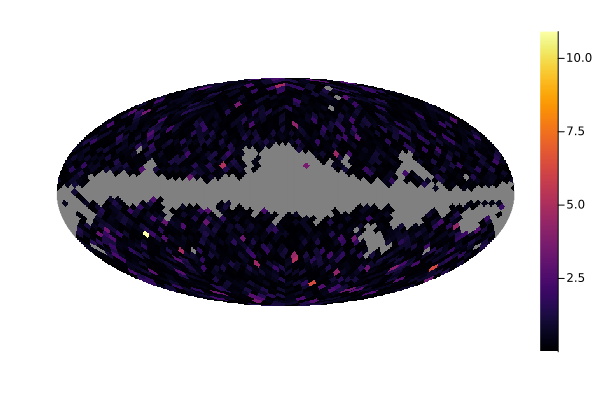

In [30]:
plot(NLLs_HMap[1000])

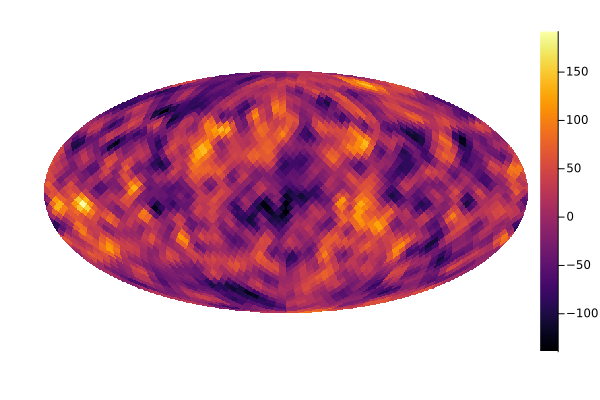

In [31]:
plot(samples_HMap[1000])

In [32]:
# function count_nothings(NLLs, pixels, samples)
#     nothing_count = 0
#     something_count = 0

#     for i in 1:pixels
#         for j in 1:samples
#             if NLLs[i,j] === nothing
#                 nothing_count += 1
#             else
#                 something_count += 1
#             end
#         end
#     end

#     return nothing_count, something_count
# end

# nothing_count, something_count = count_nothings(NLLs, pixels, samples)

# println(nothing_count)
# println(something_count)

In [33]:
# switch_vector = Vector{Int64}()
# for i in 1:(pixels-1)
#     if (NLLs[i,1] == nothing && NLLs[i+1, 1] != nothing) || (NLLs[i,1] != nothing && NLLs[i+1, 1] == nothing)
#         append!(switch_vector, i)
#     end
# end
# println(length(switch_vector))
# println(switch_vector)

In [36]:
unmasked_pixels = 0
for i in 1:pixels
    if NLLs[i, 1] !== nothing
        global unmasked_pixels += 1
    end
end

unmasked_NLLs = Matrix{Float64}(undef, unmasked_pixels, samples)
unmasked_pixels = 0
for i in 1:pixels
    if NLLs[i, 1] !== nothing
        global unmasked_pixels += 1
        unmasked_NLLs[unmasked_pixels,:] = NLLs[i,:]
    end
end

In [37]:
unmasked_pixels

2384

In [38]:
unmasked_NLLs

2384×2000 Matrix{Float64}:
 1.09033      1.07099      1.07577      …  0.397864    0.399162    0.420281
 0.610307     0.600114     0.605901        0.188677    0.153564    0.119703
 0.0112976    0.0124335    0.00720536      0.00156494  0.00217712  0.0054948
 0.883137     0.838183     0.868852        0.0273612   0.0215013   0.0218674
 2.04663      2.05175      2.15517         0.143986    0.146895    0.139754
 0.18318      0.212569     0.190711     …  0.0338109   0.0489026   0.0637061
 0.223033     0.225572     0.189904        0.00496425  0.00540101  0.008993
 1.10724      1.12142      1.24437         0.321253    0.330109    0.306277
 0.469458     0.459053     0.43314         1.43483     1.58377     1.70336
 0.583922     0.58118      0.469134        0.497177    0.479311    0.463283
 0.154223     0.150642     0.196458     …  0.0500833   0.0522287   0.0386726
 0.000169912  0.000451277  4.23747e-6      0.162287    0.194849    0.211714
 0.281792     0.285986     0.313185        0.0821838   0.0

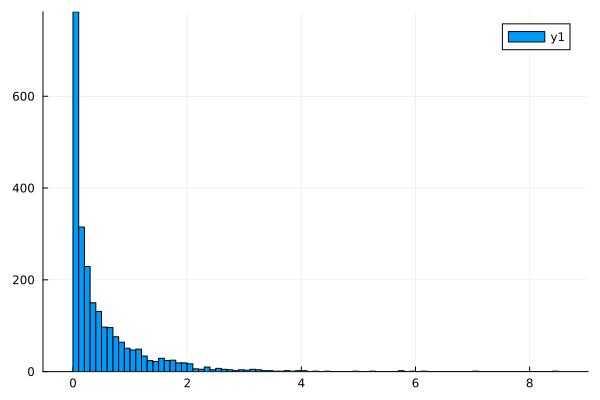

In [39]:
histogram(unmasked_NLLs[:,1])

In [40]:
# psis_result = Vector{PSISResult{Float64, Vector{Float64}, Int64, Int64, PSIS.GeneralizedPareto{Float64}}}(undef, unmasked_pixels);
# for i in 1:unmasked_pixels
#     psis_result[i] = psis(unmasked_NLLs[i,:])
# end

psis_result = Vector{PSISResult{Float64, Vector{Float64}, Int64, Int64, PSIS.GeneralizedPareto{Float64}}}(undef, pixels);
for i in 1:pixels
    psis_result[i] = psis(NLLs_pixels[i,:])
end

┌ Warning: Tail contains non-finite values. Generalized Pareto distribution cannot be reliably fit.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:294
┌ Warning: Tail contains non-finite values. Generalized Pareto distribution cannot be reliably fit.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:294
┌ Warning: Tail contains non-finite values. Generalized Pareto distribution cannot be reliably fit.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:294
┌ Warning: Pareto shape k = 0.74 > 0.7. Resulting importance sampling estimates are likely to be unstable.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:365
┌ Warning: Pareto shape k = 0.79 > 0.7. Resulting importance sampling estimates are likely to be unstable.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:365
┌ Warning: Pareto shape k = 0.81 > 0.7. Resulting importance sampling estimates are likely to be unstable.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:365
┌ Warning: Pareto shape k = 0.72 > 0.7. Resulting impor

Pareto Shapes: [-0.1457863464451024, 0.0803189164532133, -0.32423765159530094, -0.1256777420682806, -0.28051760494394984, -0.33540596457224153, 0.35298022543522856, -0.544689081126912, -0.1708278874828545, -0.2612051410501878, -0.3744725090872861, -0.1576331573485588, -0.23964777425808353, -0.17136619670167463, -0.04903503108327963, 0.10171793708885216, 0.10224489264931805, 0.052358564712976285, -0.08686792211557864, -0.3848588243585738, -0.19525512349183477, -0.03035700166661135, -0.11012181772729764, -0.009667386949833183, 0.2858817525398583, -0.3176129505901376, 0.08399648361407495, 0.0905781494265495, -0.13506004623533385, -0.26237103707587495, -0.03217471123027387, 0.27710444341485146, 0.2185687316670264, -0.009562990648645091, 0.24112021873598052, 0.066217174392037, -0.32127048390451507, -0.27752755656820405, 0.03966629157599764, 0.07058618457983243, -0.19567298947125095, -0.2505453292277495, -0.39197378125708365, -0.2527417302610288, -0.15051183064929072, -0.2762535791605081, -0

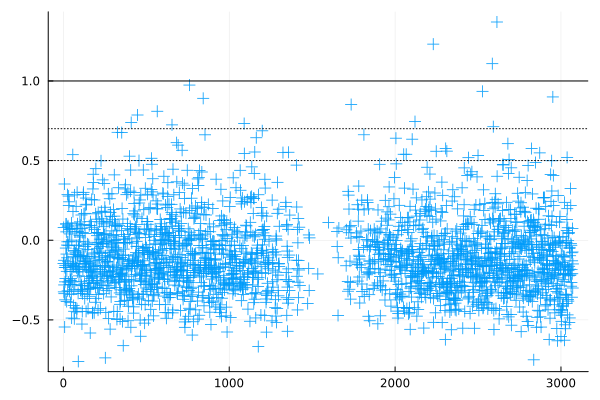

In [41]:
pareto_shapes = Vector{Float64}()
for i in 1:pixels
    append!(pareto_shapes, psis_result[i].pareto_shape)
end
println("Pareto Shapes: ", pareto_shapes)

shape_plot = Plots.scatter(pareto_shapes; marker =:+, markersize=6, legend = false, linewidth=2)
hline!([0.5,0.7], linestyle=:dot, color =:black)
hline!([1.0], linestyle=:solid, color=:black)

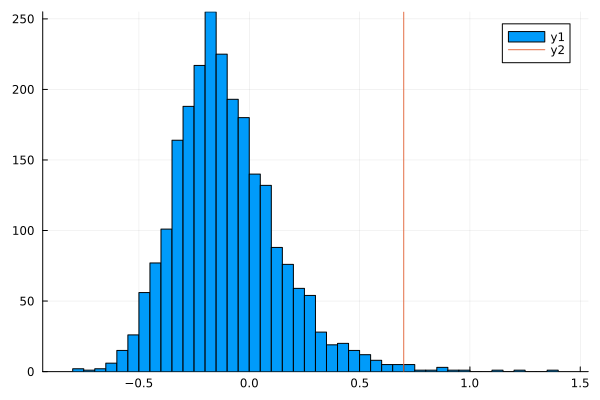

In [42]:
psis_shapes_hist = histogram(pareto_shapes)
vline!([0.7])

In [43]:
failure_count= 0 
for i in 1:pixels
    if pareto_shapes[i] > 0.7
        global failure_count += 1
    end
end
failure_rate = failure_count / unmasked_pixels
println(failure_count)
println(failure_rate)

15
0.006291946308724832


In [44]:
mkpath("PSIS_results/$(samples)_$(nside)/$runname")
npzwrite("PSIS_results/$(samples)_$(nside)/$runname/pareto_shapes.npy", pareto_shapes)
npzwrite("PSIS_results/$(samples)_$(nside)/$runname/failure_rate.npy", [failure_count, unmasked_pixels, failure_rate])

mkpath("NLLs/$(samples)_$(nside)/$runname")
npzwrite("NLLs/$(samples)_$(nside)/$runname/NLLs.npy", NLLs_pixels)

Plots.savefig(shape_plot, "PSIS_results/$(samples)_$(nside)/$runname/pareto_shapes.png")
Plots.savefig(psis_shapes_hist, "PSIS_results/$(samples)_$(nside)/$runname/pareto_shapes_histogram.png")

"/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/PSIS_results/2000_16/2yjXc/pareto_shapes_histogram.png"

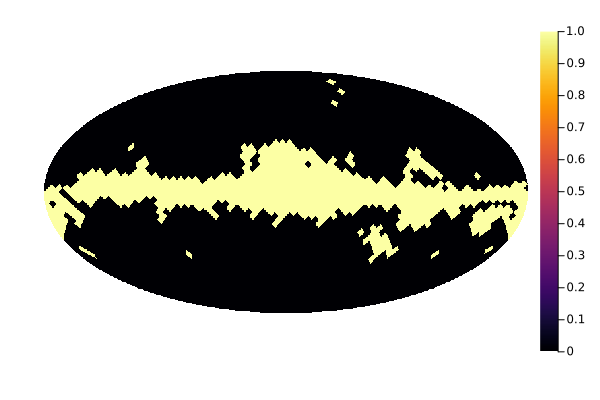

In [45]:
plot(mask_nside)

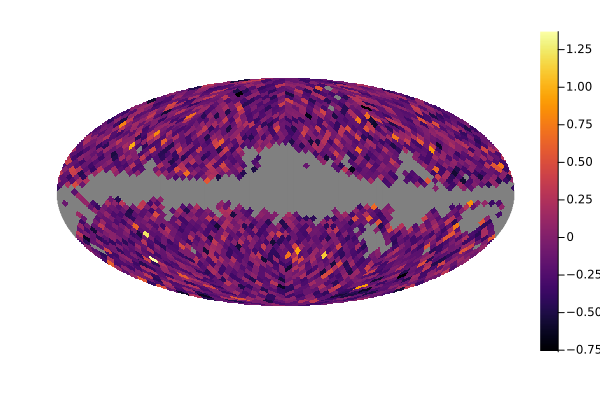

In [46]:
shape_mapping = HealpixMap{Float64, RingOrder, Vector{Float64}}(pareto_shapes)
shape_map = plot(shape_mapping)

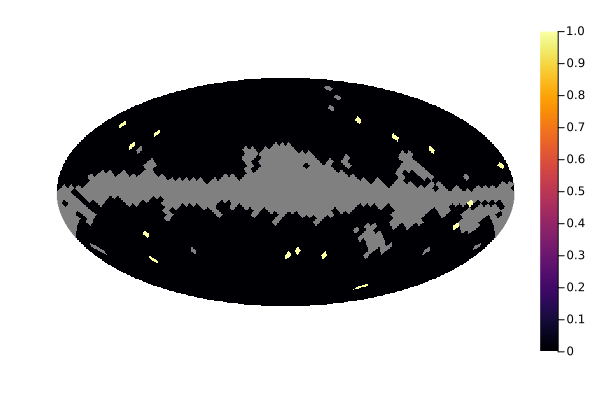

In [47]:
failure_vector = Vector{Float64}(undef, pixels)

for i in 1:pixels
    if isnan(pareto_shapes[i])
        failure_vector[i] = NaN
    elseif pareto_shapes[i] > 0.7
        failure_vector[i] = 1.0
    else
        failure_vector[i] = 0.0  
    end
end

failure_mapping = HealpixMap{Float64, RingOrder, Vector{Float64}}(failure_vector)
failure_map = plot(failure_mapping)

In [30]:
Plots.savefig(failure_map, "PSIS_results/$(samples)_$(nside)/$runname/failure_map.png")
Plots.savefig(shape_map, "PSIS_results/$(samples)_$(nside)/$runname/shape_map.png")

"/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/PSIS_results/2000_16/2yjXc/shape_map.png"

PIT PORTION

In [31]:
#Optionally load NLLs
#NLLs_pixels = npzread("/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/NLLs/2000_16/2yjXc/NLLs.npy")

In [48]:
comparison_values = Array{Float64}(undef, length(mask_nside), samples)

# # for i in 1:length(mask_nside)
# #     for j in 1:samples
# #         for k in 1:pixels

for i in 1:10
    for j in 1:10
        for k in 1:10
            data = gen_DMap.pixels[i]
            comparison_values[i,j] = data
        end
    end
end

In [49]:
# comparison_values

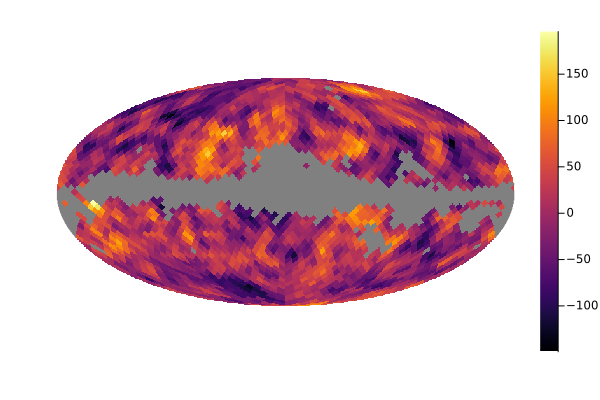

In [50]:
NaN_Mask = map(x -> x === 0.0 ? NaN : x, gen_HMap)

gen_HMap = HealpixMap{Float64, RingOrder, Vector{Float64}}(NaN_Mask)

plot(gen_HMap)

In [95]:
mask = isnan.(gen_HMap.pixels)

for i in 1:samples
    sample_pixels = copy(samples_HMap[i].pixels)
    sample_pixels[mask] .= NaN
    sample_masked = HealpixMap{Float64, RingOrder, Vector{Float64}}(sample_pixels)
    samples_HMap[i] = sample_masked
end

In [98]:
loo_pit = Vector{Float64}(undef, pixels)

for i in 1:pixels
    w = psis_result[i].weights
    w ./= sum(w)

    loo_pit[i] = sum(w .* (samples_HMap[1][i] .<= gen_HMap[i]))
end

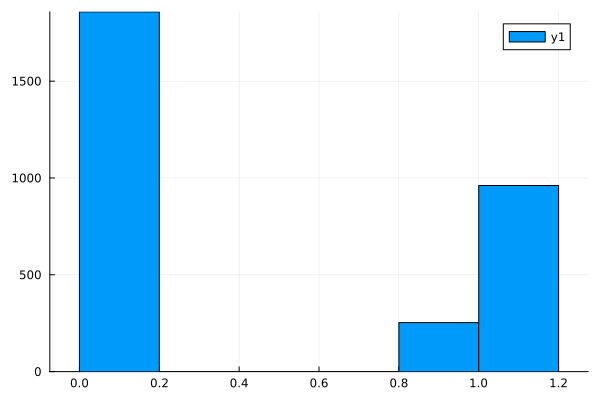

In [99]:
histogram(loo_pit)

### WORK IN PROGRESS

In [128]:
using Distributions
using StatsPlots

# ------------------------------------------------------------
# Build mask from the observed map
# ------------------------------------------------------------

# Pixels that are actually observed
mask = .!isnan.(gen_HMap.pixels)

y_obs = gen_HMap.pixels[mask]

npix = count(mask)
samples = length(samples_HMap)

preds = Matrix{Float64}(undef, samples, npix)

# ------------------------------------------------------------
# Build posterior predictive maps
# ------------------------------------------------------------

for s in 1:samples

    #
    # sample_HAlm is the posterior sample for draw s
    #
    θ = sampled_params[:, s]

    alm = θ[1:end-(lmax+1)]

    sample_alm = x_vec2vecmat(alm, lmax, 1, comm, root=root)

    sample_HAlm = from_alm_to_healpix_alm(
        sample_alm,
        lmax,
        1,
        comm,
        root=root
    )[1]

    #
    # Apply the same beam/pixel window used to generate the data
    #
    pred_HAlm = almxfl(sample_HAlm, BP_l)

    #
    # Convert to map
    #
    pred_HMap = alm2map(pred_HAlm, nside)

    #
    # Add the SAME observational noise as Measurement()
    #
    noise = rand(
        MvNormal(
            zeros(length(pred_HMap.pixels)),
            Diagonal(N)
        )
    )

    pred_HMap.pixels .+= noise

    #
    # Apply the SAME survey mask
    #
    pred_HMap[mask_nside .== 1] .= 0

    #
    # Store only the observed pixels
    #
    preds[s, :] .= pred_HMap.pixels[mask]

end

# ------------------------------------------------------------
# Ordinary PIT
# ------------------------------------------------------------

pit = vec(mean(preds .<= permutedims(y_obs), dims=1))

histogram(
    pit,
    bins=20,
    normalize=:pdf,
    xlabel="PIT",
    ylabel="Density",
    title="Posterior Predictive PIT"
)

LoadError: MethodError: no method matching alm2map(::Alm{ComplexF64, Vector{ComplexF64}}, ::Int64)
The function `alm2map` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  alm2map(::Any, ::Any, [91m::Integer[39m)
[0m[90m   @[39m [35mMain[39m [90m~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/[39m[90m[4mAD_parallSHT.jl:1[24m[39m
